# Delicious Asian and Indian Cuisines 

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from imblearn.over_sampling import SMOTE
import seaborn as sns

In [2]:
df = pd.read_csv('../data/cuisines.csv')

In [3]:
df.head()

,Unnamed: 0,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,65,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,66,indian,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,67,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,68,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,69,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [5]:
df['cuisine'].unique()

array(['indian', 'thai', 'chinese', 'japanese', 'korean'], dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2448 entries, 0 to 2447
Columns: 385 entries, Unnamed: 0 to zucchini
dtypes: int64(384), object(1)
memory usage: 7.2+ MB


<Axes: ylabel='cuisine'>

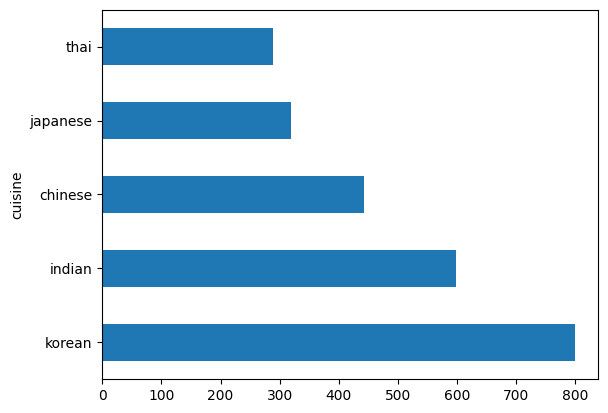

In [16]:
# Finding rhe distribution of data per cuisine
df['cuisine'].value_counts().plot.barh()
# Visualizing the distribution of data per cuisine
# plt.figure(figsize=(14,8))
# sns.countplot(y='cuisine', data=df)
# plt.title('Distribution of data per cuisine')
# plt.show()


In [9]:
# Find out how much data is available for each cuisine

thai_df = df[(df['cuisine'] == 'thai')]
japanese_df = df[(df['cuisine'] == 'japanese')]
chinese_df = df[(df['cuisine'] == 'chinese')]
indian_df = df[(df['cuisine'] == 'indian')]
korean_df = df[(df['cuisine'] == 'korean')]

print(f'thai df: {thai_df.shape}')
print(f'japanese df: {japanese_df.shape}')
print(f'chinese df: {chinese_df.shape}')
print(f'indian df: {indian_df.shape}')
print(f'korean df: {korean_df.shape}')




thai df: (289, 385)
japanese df: (320, 385)
chinese df: (442, 385)
indian df: (598, 385)
korean df: (799, 385)


In [ ]:
# Discovering ingredients
def create_ingredient_df(df):
    ingredient_df = df.T.drop(['cuisine','Unnamed: 0']).sum(axis=1).to_frame('value')
    ingredient_df = ingredient_df[(ingredient_df.T != 0).any()]
    ingredient_df = ingredient_df.sort_values(by='value', ascending=False,
    inplace=False)
    return ingredient_df

<Axes: >

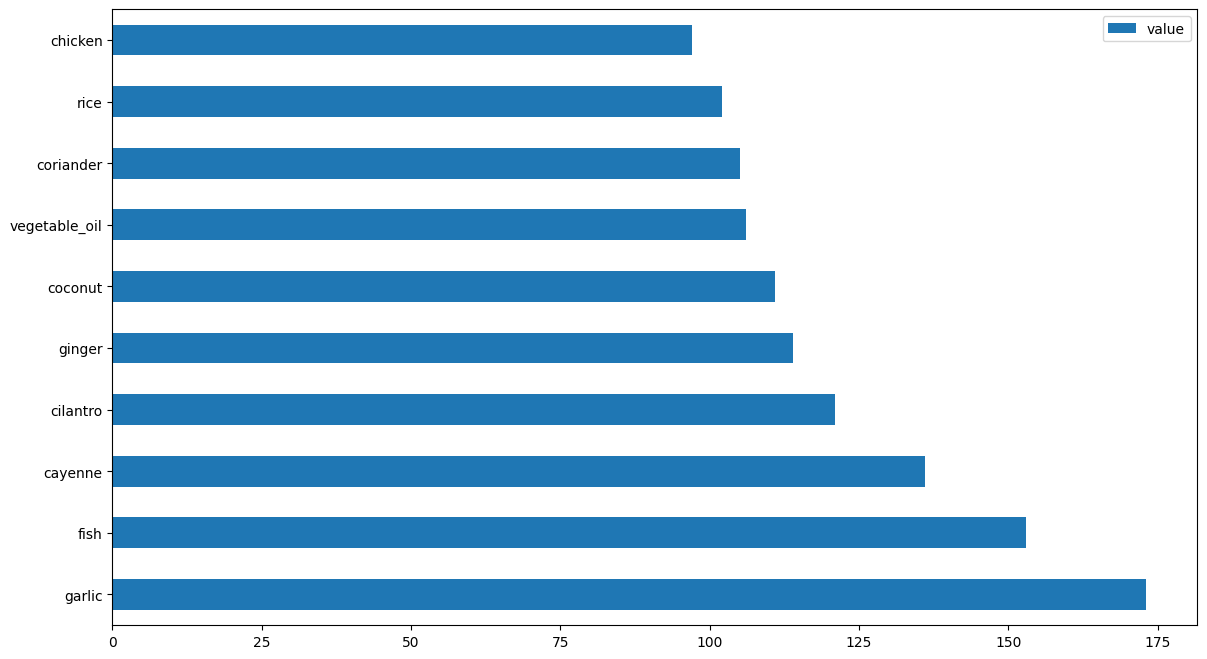

In [17]:
# Call create_ingredient() and plot it

thai_ingredient_df = create_ingredient_df(thai_df)
thai_ingredient_df.head(10).plot.barh(figsize=(14,8))

<Axes: >

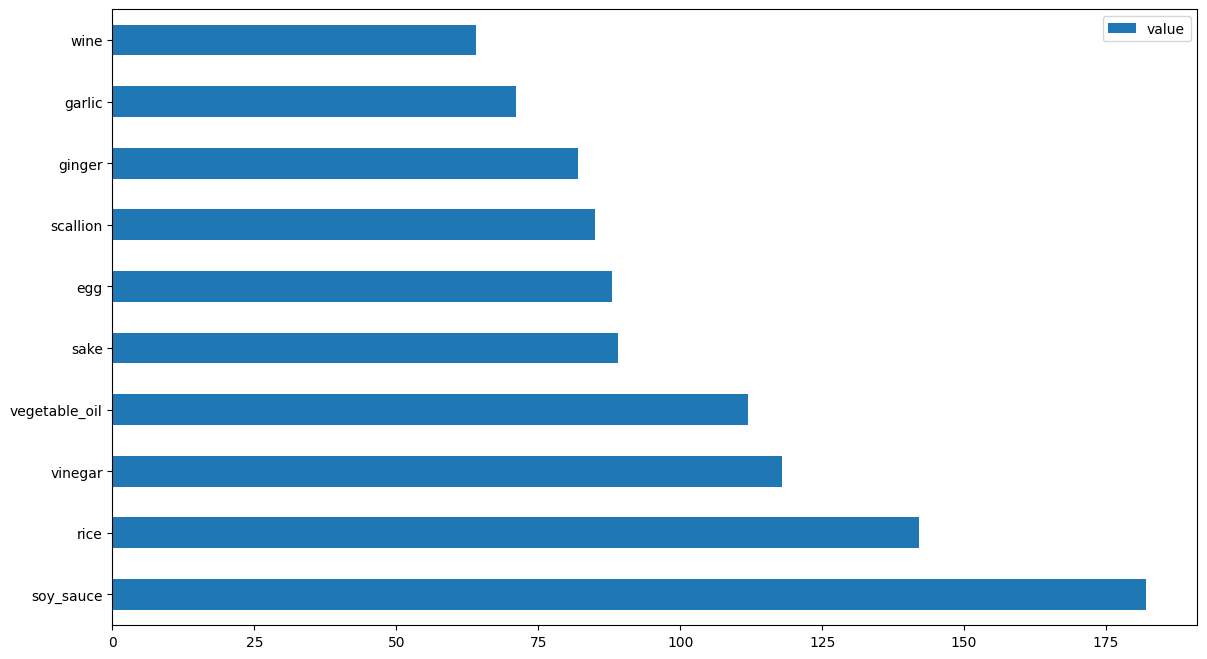

In [19]:
japanese_ingredient_df = create_ingredient_df(japanese_df)
japanese_ingredient_df.head(10).plot.barh(figsize=(14,8))



<Axes: >

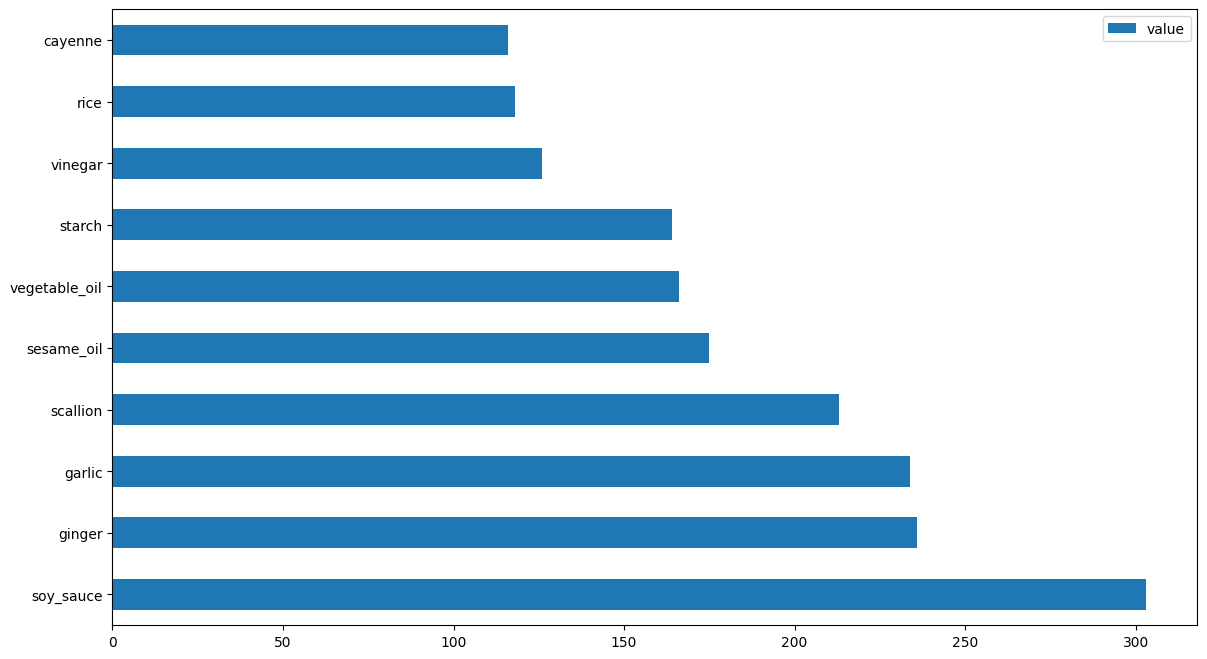

In [20]:
chinese_ingredient_df = create_ingredient_df(chinese_df)
chinese_ingredient_df.head(10).plot.barh(figsize=(14,8))


<Axes: >

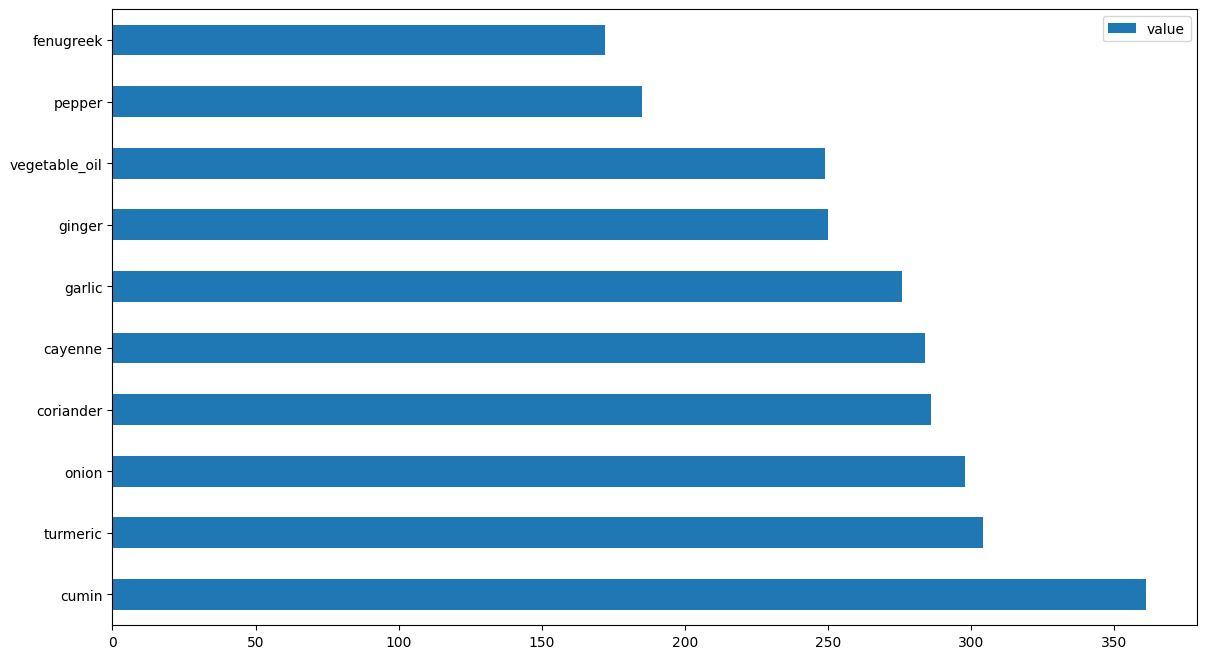

In [21]:
indian_ingredient_df = create_ingredient_df(indian_df)
indian_ingredient_df.head(10).plot.barh(figsize=(14,8))









<Axes: >

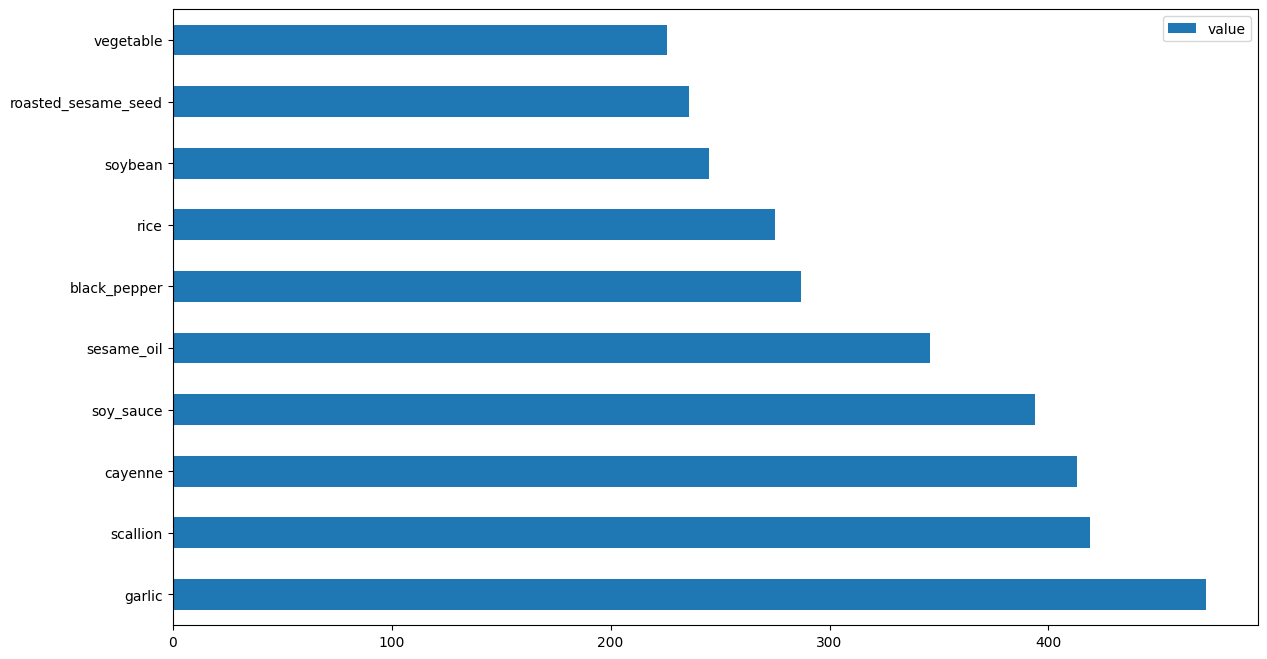

In [22]:
korean_ingredient_df = create_ingredient_df(korean_df)
korean_ingredient_df.head(10).plot.barh(figsize=(14,8))

In [27]:
# Drop the most common ingredients that create confusion between distinct cuisines: rice, garlic and ginger

features_df = df.drop(['cuisine','Unnamed: 0', 'rice', 'garlic', 'ginger'], axis=1)
labels_df = df.cuisine #.unique()
features_df.head()

,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [31]:
# labels_df.unique()
labels_df.head(10)

0    indian
1    indian
2    indian
3    indian
4    indian
5    indian
6    indian
7    indian
8    indian
9    indian
Name: cuisine, dtype: object

In [ ]:
# Balance the data
oversample = SMOTE()
transformed_feature_df, transformed_label_df = oversample.fit_resample(features_df, labels_df)

In [32]:
print(f'new label count: {transformed_label_df.value_counts()}')
print(f'old label count: {df.cuisine.value_counts()}')

new label count: cuisine
indian      799
thai        799
chinese     799
japanese    799
korean      799
Name: count, dtype: int64
old label count: cuisine
korean      799
indian      598
chinese     442
japanese    320
thai        289
Name: count, dtype: int64


In [ ]:
# Saving balanced data into a new dataframe
transformed_df = pd.concat([transformed_label_df, transformed_feature_df],axis=1, join='outer')

transformed_df.info()
transformed_df.to_csv("../data/cleaned_cuisines.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3995 entries, 0 to 3994
Columns: 381 entries, cuisine to zucchini
dtypes: int64(380), object(1)
memory usage: 11.6+ MB


In [34]:
transformed_df.head()

,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,indian,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
